# Congestion Pricing and NYC Drivers

On 5 January 2025 New York started charging a toll to enter Manhattan below 60th Street. This notebook builds the tables and figures behind the report: how the toll changed high volume for-hire vehicle (Uber/Lyft) trips and driver earnings.

Run it from top to bottom. The functions it calls live in `scripts/`. Setup steps are in `README.md`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from scripts import (clean, config, download, explore, external, models,
                     plots, spark_io, zones)

# Every figure uses the shared style
plt.style.use(config.STYLE_FILE)

months = config.months_to_process()
print(f"QUICK_RUN = {config.quick_run()}: {len(months)} months, "
      f"{months[0]} to {months[-1]}")

QUICK_RUN = False: 36 months, (2023, 1) to (2025, 12)


/Users/alina/MAST30034-Project1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Download the data

Everything is saved to `data/raw/`, and a download is skipped if its file is already there. The functions are in `scripts/download.py`.

- **TLC trip records:** one parquet file per month of 2023-2025 for high volume for-hire vehicles, 36 files and about 16 GB.
- **External:** the MTA list of tolled (CBD) zones, the TLC taxi zone lookup and shapefile, the MTA monthly CBD speeds, and NOAA daily weather for Central Park.

In [2]:
tlc_files = download.download_tlc(months)
download.split_large_row_groups(tlc_files)

# Rows x columns of every raw TLC file, used by the step table of
# Section 3.5
tlc_shapes = download.parquet_shapes(tlc_files)
tlc_shapes["service"] = tlc_shapes["file"].str.split("_").str[0]

TLC: 36 files, 36 already downloaded, 0 to download


In [3]:
external_files = download.download_external()

## 2. Prepare the external data

### 2.1 Zone labels

The analysis compares trips that touch the tolled area (`cbd`) with trips that don't (`control`). Zones just outside the CBD fit neither group: riders can walk out of the CBD and drivers can wait at its edge, so counting them as control would overstate the toll's effect. They get their own group, the `ring`.

`zone_group_fine` splits both further, for the robustness checks in Section 6.3: the ring into zones across a street and zones across a river, and the control zones into those nearest the ring (`control_near`) and the rest.

The first table counts the zones in each group; the second lists the ring zones, nearest first.

In [4]:
zone_labels = zones.build_zone_labels()
print(f"Zone labels: {zone_labels.shape[0]} rows x {zone_labels.shape[1]} "
      f"columns, saved to {zones.LABELS_FILE.name}")
display(plots.flat(pd.crosstab(  # noqa: F821
    zone_labels["zone_group_fine"], zone_labels["zone_group"], margins=True,
    margins_name="Total")))

# The ring zones, nearest first
plots.flat(zone_labels[zone_labels["zone_group"] == "ring"]
           .sort_values("distance_to_cbd_ft")
           [["LocationID", "Borough", "Zone", "distance_to_cbd_ft",
             "zone_group_fine"]])

Zone labels: 265 rows x 8 columns, saved to zone_labels.csv


Fine zone group,CBD,Control,Ring,Total
CBD,38,0,0,38
"Control, far",0,190,0,190
"Control, near",0,16,0,16
"Ring, across water",0,0,13,13
"Ring, adjacent",0,0,6,6
Total,38,206,19,263


Zone ID,Borough,Zone,Distance to CBD (ft),Fine zone group
141,Manhattan,Lenox Hill West,0,"Ring, adjacent"
43,Manhattan,Central Park,0,"Ring, adjacent"
237,Manhattan,Upper East Side South,0,"Ring, adjacent"
143,Manhattan,Lincoln Square West,0,"Ring, adjacent"
142,Manhattan,Lincoln Square East,0,"Ring, adjacent"
140,Manhattan,Lenox Hill East,0,"Ring, adjacent"
202,Manhattan,Roosevelt Island,908,"Ring, across water"
145,Queens,Long Island City/Hunters Point,1334,"Ring, across water"
34,Brooklyn,Brooklyn Navy Yard,1374,"Ring, across water"
33,Brooklyn,Brooklyn Heights,1416,"Ring, across water"


### 2.2 Weather and public holidays

Snow, heavy rain and holidays change how many people take a taxi, so both are controls in the Section 6 models. The Central Park station stands in for the whole city, and `rain_mm` is NOAA's total precipitation, so it includes melted snow. The holiday dates are typed out in `external.HOLIDAYS` rather than taken from a package, so the pinned requirements don't grow.

In [5]:
weather = external.load_weather()
print(f"Weather: {weather.shape[0]:,} rows x "
      f"{weather.shape[1]} columns, "
      f"{weather['date'].min():%Y-%m-%d} to "
      f"{weather['date'].max():%Y-%m-%d}")
print(f"Public holidays: {len(external.HOLIDAYS)} dates")

Weather: 1,096 rows x 6 columns, 2023-01-01 to 2025-12-31
Public holidays: 35 dates


## 3. Clean the taxi data

The functions are in `scripts/clean.py`. Every check and cut-off runs on the full data, because some problems are concentrated in one vendor or one year and a sample could miss them.

### 3.1 Read the raw files

`spark_io.read_service` reads every month, keeps only the columns used below and casts them to one schema, so the months can be stacked.

In [6]:
spark = spark_io.get_spark()
spark.sparkContext.setLogLevel("ERROR")

# Raw trips with the kept columns, plus trip_seconds, trip_hours, speed_mph
raw = {service: clean.add_trip_time(
           spark_io.read_service(spark, service, months), service)
       for service in config.SERVICES}

# Raw column count for the step table (it differs between years)
raw_columns = {}
for service in config.SERVICES:
    counts = tlc_shapes.loc[tlc_shapes["service"] == service, "columns"]
    low, high = counts.min(), counts.max()
    raw_columns[service] = str(low) if low == high else f"{low}-{high}"

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/21 00:20:01 WARN Utils: Your hostname, Alinas-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.247 instead (on interface en0)
26/09/21 00:20:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/21 00:20:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/09/21 00:20:02 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


### 3.2 Nulls

Nulls in every kept column, counted on the full data by month and company. The table below adds the months up by year and leaves out columns with no nulls.

**Decision:** no row is dropped for a null. `cbd_congestion_fee`, the only column with any nulls, is null before 2025 because the fee didn't exist then.

In [7]:
nulls = {service: clean.null_counts(raw[service], service)
         for service in config.SERVICES}

# Nulls by year and company
plots.flat(clean.nulls_by_year(nulls["fhvhv"], ["hvfhs_license_num"]),
           merge=["year"])

### 3.3 Distributions and outlier cut-offs

Quantiles of trip length (minutes), distance (miles), average speed (mph) and money (`driver_pay`), over every raw trip with a positive time and distance. They are read off full-data histograms with fine bins (0.1 minute, 0.05 mile, 0.1 mph, $0.25), so they are accurate to one bin; a value below the first bin shows as, for example, `<0.05`.

In [8]:
quantiles = {s: clean.distribution_quantiles(raw[s], s)
             for s in config.SERVICES}
plots.flat(pd.concat(quantiles, axis=1))

**Cut-offs** (constants at the top of `scripts/clean.py`): trip length from 1 minute to 5 hours, distance at most 100 miles, average speed at most 60 mph, and money at most $500. Each sits above the matching 99.9th percentile in the table above, past which the distributions thin out into impossible values, and together they remove 0.02% of high volume for-hire vehicle rows (Section 3.5).

### 3.4 Time bands

The first table gives the 2025 CBD fee's values and how many pickup hours each appears in. One flat value in every hour means the fee itself gives no reason to split the day, so the bands follow the demand curve and the car toll's hours instead:

| Band | Pickup hours |
|------|-------------|
| `overnight` | 21:00-04:59 |
| `morning_peak` | 05:00-09:59 |
| `midday` | 10:00-15:59 |
| `evening` | 16:00-20:59 |

The second table checks the fee column against the zone rule used from here on: a trip is treated when either end is in the CBD. The fee also covers trips that only pass through the CBD, which two trip ends can't show, so those count as control.

In [9]:
# CBD fee values on 2025 trips, and how many pickup hours each appears in
display(plots.flat(pd.concat({s: clean.cbd_fee_values(raw[s], s)  # noqa: F821
                              for s in config.SERVICES}, names=["service"]),
                   merge=["service"]))

# Does the zone rule find the trips the fee was charged on? The fee also
# covers trips that only pass through the CBD, which the two trip ends
# can't show, so these trips count as control
plots.flat(pd.concat({s: clean.cbd_fee_vs_zone_rule(raw[s], zone_labels)
                      for s in config.SERVICES},
                     names=["service"]).round(2),
           merge=["service"])

### 3.5 Cleaning

Every removal rule in the order it is applied, with its reason and the rows x columns left after it, all from one pass over the full data.

In [10]:
steps = {}
for service in config.SERVICES:
    steps[service] = clean.step_shapes(raw[service], service,
                                       raw_columns[service])
    print(service)
    display(plots.flat(steps[service]))  # noqa: F821

fhvhv


Step,Reason,Rows,Columns,Removed,Removed (%)
Raw,Raw files,715550152,24-25,0,0.000
Keep columns,Keep only the columns we need,715550152,10,0,0.000
Pickup in file month,Pickup date outside the month of the file (wrong dates),715550152,10,0,0.000
Drop-off after pickup,Drop-off time before or equal to pickup time,715519470,10,30682,0.004
Positive driver pay,Zero or negative driver pay,714346062,10,1173408,0.164
Trip length,Trip shorter than 1 minute or longer than 5 hours,714293200,10,52862,0.007
Distance cap,Distance over 100 miles,714228315,10,64885,0.009
Speed cap,Average speed over 60 mph (impossible in NYC traffic),714221992,10,6323,0.001
Money cap,driver_pay over $500,714221778,10,214,0.000
Known zones,"Pickup or drop-off in zone 264 (Unknown) or 265 (Outside of NYC), and the other end is not in the CBD, so the trip group is unknown",694437031,10,19784747,2.765


### 3.6 New columns

`clean.add_columns` adds these to the cleaned trips, next to `trip_hours` from Section 3.1 (drop-off minus pickup, in real instants, so trips across a daylight saving change get the right length):

- `earnings`: `driver_pay`, and null on zero-distance trips. Those trips are still kept and counted.
- `earnings_per_engaged_hour`: `earnings / trip_hours`, also null for shared high volume for-hire vehicle rides, whose hour is split with another trip.
- `pickup_group`, `dropoff_group`: the five-level `zone_group_fine` of Section 2.1.
- `trip_group` (five levels) and `trip_group_coarse`: a trip is `treated` if either end is in the CBD, `ring` if either end is in the ring and neither in the CBD, and `control` otherwise.
- `date`, `hour`, `time_band`, `day_of_week` (1 = Monday) and `after_toll`.

The table below gives the share of trips with known earnings per engaged hour, by year and coarse trip group.

In [11]:
trips = {s: clean.add_columns(clean.clean(raw[s], s), s, spark, zone_labels)
         for s in config.SERVICES}

coverage = {}
for service in config.SERVICES:
    print(f"{service}: trips with known earnings per engaged hour (%)")
    coverage[service] = clean.earnings_coverage(trips[service])
    display(plots.flat(coverage[service].round(1)))  # noqa: F821

fhvhv: trips with known earnings per engaged hour (%)


Year,Treated,Ring,Control
2023,99.2,99.2,99.4
2024,98.4,98.2,98.4
2025,98.8,98.3,98.0


### 3.7 Summary table

One row per **service x pickup zone x drop-off group x date x time band**, holding `trips`, `trips_with_earnings`, `total_earnings`, `median_earnings_per_engaged_hour` and the group and calendar columns of Section 3.6. The pickup zone and drop-off group together fix the trip group, so the five groups can be compared with a pandas `groupby` instead of a new Spark run.

Medians are taken over every trip (`percentile_approx`, within 0.1% of the true rank), and every combination with no trips gets a row with 0 trips, so zeros are not silently missing. Spark builds the table one month at a time and saves each month to `data/curated/summary_parts/` for reuse; pass `overwrite=True` after changing a cleaning rule. The assert below checks the trips in the table back against the step counts of Section 3.5.

In [12]:
summary = clean.build_summary(spark, zone_labels, months)
print(f"Summary table: {summary.shape[0]:,} rows x {summary.shape[1]} "
      f"columns, saved to {clean.SUMMARY_FILE.name}")

# The trips in the summary must equal the rows left after cleaning
for service in config.SERVICES:
    in_summary = summary.loc[summary["service"] == service, "trips"].sum()
    assert in_summary == steps[service]["rows"].iloc[-1], service

print(f"Rows with 0 trips: {(summary['trips'] == 0).mean():.1%}")
plots.flat(summary.groupby(["service", "trip_group",
                            summary["date"].dt.year.rename("year")])["trips"]
           .sum().unstack("year")
           .reindex(list(clean.TRIP_GROUPS.values()), level="trip_group"),
           merge=["service"])

fhvhv: 36 months summarised


Summary table: 5,940,320 rows x 14 columns, saved to trip_summary.parquet
Rows with 0 trips: 13.0%


## 4. Join the external data onto the summary table

Weather and the holiday flag join on the date. No join may change the number of rows, which the assert inside `join_external` checks. The result is saved as `data/curated/model_table.parquet`, the table the Section 6 models are fitted to.

In [13]:
model_table, join_shapes = external.join_external(summary, weather)
display(plots.flat(join_shapes))  # noqa: F821
print(f"Saved to {external.MODEL_TABLE_FILE.name}")
print(f"Rows on a public holiday: {model_table['is_holiday'].mean():.1%}")

Step,Rows,Columns
summary table (Step 3),5940320,14
+ daily weather (Central Park),5940320,19
+ public holiday flag,5940320,20


Saved to model_table.parquet
Rows on a public holiday: 3.2%


## 5. Explore the data and make maps

Functions are in `scripts/explore.py` (tables) and `scripts/plots.py` (figures). Report figures are saved to `plots/` as PDF.

Unless a subsection says otherwise, before-and-after comparisons use the **toll period, 5 January to 31 December 2025**, against **the same dates in 2024**, so both periods cover the same season.

### 5.1 Distributions before and after cleaning

Every raw row and every cleaned trip, binned on the full data. `money` is `driver_pay` in both, so the two curves measure the same thing. Values past either end of the range are added to the end bins, so the outliers stay visible. The lines under the figure give the share of rows in the end bins of the per-hour histograms.

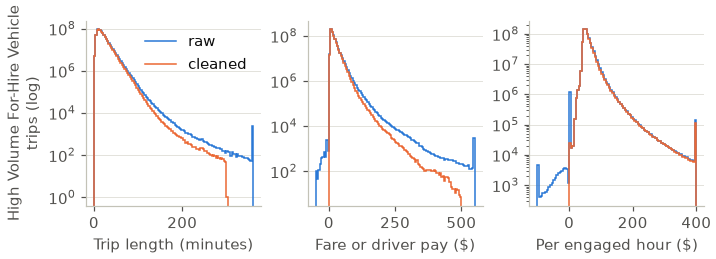

fhvhv, raw: 0.001% under -$95 an hour, 0.021% at $395 or more
fhvhv, cleaned: 0.000% under -$95 an hour, 0.017% at $395 or more


In [14]:
money_labels = {"trip_minutes": "Trip length (minutes)",
                "money": "Fare or driver pay ($)",
                "money_per_hour": "Per engaged hour ($)"}
before_cleaning, after_cleaning = {}, {}
for service in config.SERVICES:
    before_cleaning[service] = explore.histograms(
        explore.add_money_columns(raw[service], service), explore.HIST_SPECS)
    after_cleaning[service] = explore.histograms(
        explore.add_money_columns(trips[service], service),
        explore.HIST_SPECS)

plots.before_after_histograms(before_cleaning, after_cleaning, money_labels)
plt.show()

# Share of trips in the end bins of the per-hour histograms
for service in config.SERVICES:
    for name, tables in [("raw", before_cleaning),
                         ("cleaned", after_cleaning)]:
        counts = tables[service]["money_per_hour"]["count"]
        print(f"{service}, {name}: "
              f"{counts.iloc[0] / counts.sum():.3%} under -$95 an hour, "
              f"{counts.iloc[-1] / counts.sum():.3%} at $395 or more")

### 5.2 Nulls, and what the cleaning removes from each trip group

The first table gives rows with a null as a share of raw rows, by year.

Cleaning could bias the treated-versus-control comparison if it removed a bigger share of one group after the toll than before. The second table counts each raw row once, under the first rule it fails, as a share of that group's raw rows in the year. `unknown_zone` holds trips with an end in zone 264 or 265 that touch neither the CBD nor the ring, so they have no group.

In [15]:
for service in config.SERVICES:
    print(f"{service}: rows with a null (%)")
    display(plots.flat(  # noqa: F821
        explore.null_shares(nulls[service]).round(2)))

fhvhv: rows with a null (%)


Year,CBD congestion fee
2023,100
2024,100
2025,0


In [16]:
removals = {s: explore.removals_by_group(raw[s], s, spark, zone_labels)
            for s in config.SERVICES}
for service in config.SERVICES:
    print(f"{service}: share of each group's raw rows removed (%)")
    display(plots.flat(  # noqa: F821
        explore.removal_shares(removals[service]).round(2)))

fhvhv: share of each group's raw rows removed (%)


### 5.3 Trips touching the CBD compared with the rest of the city

Each month's treated (and ring) trips divided by its control trips, indexed so the 2024 average is 100. Seasons, holidays and citywide changes hit every group, so they mostly cancel in the ratio, and a group whose ratio falls after the toll lost trips compared with the rest of the city. The figure is the report's trips figure (`fig1_relative_trips.pdf`).

The tables give, in order: each year's average of the monthly ratios; the high volume for-hire vehicle ratio month by month, so December can be read against other Decembers; trips a day by month with the change from the same month a year earlier; and the change in trips over the toll period for the five fine groups.

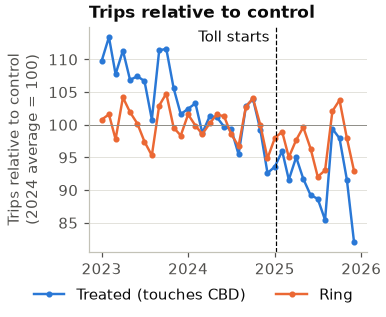

Service,Year,Treated,Ring
High Volume For-Hire Vehicle,2023,107.9,100.4
High Volume For-Hire Vehicle,2024,100.0,100.0
High Volume For-Hire Vehicle,2025,91.9,97.3


Month of year,2023,2024,2025
1,109.7,102.5,93.6
2,113.4,103.3,96.0
3,107.7,98.7,91.6
4,111.4,101.3,95.0
5,106.9,101.2,91.7
6,107.4,99.7,89.2
7,106.7,99.3,88.7
8,100.8,95.5,85.4
9,111.4,102.8,99.4
10,111.6,103.9,97.9


October to December, in points: 2023 -10.0, 2024 -11.3, 2025 -15.8


Month,Treated change (%),Control change (%)
2025-01-01,-2.0,7.3
2025-02-01,-1.4,6.1
2025-03-01,-8.1,-1.0
2025-04-01,-4.0,2.4
2025-05-01,-4.6,5.2
2025-06-01,-8.0,2.8
2025-07-01,-4.5,6.9
2025-08-01,-6.4,4.6
2025-09-01,-1.2,2.3
2025-10-01,2.5,8.7


Service,Trip group,Before,After,Change (%)
High Volume For-Hire Vehicle,"Control, far",105842665,111601787,5.4
High Volume For-Hire Vehicle,"Control, near",19432463,19634925,1.0
High Volume For-Hire Vehicle,"Ring, across water",15785359,16209614,2.7
High Volume For-Hire Vehicle,"Ring, adjacent",7508970,7519661,0.1
High Volume For-Hire Vehicle,Treated,82122421,78920152,-3.9


In [17]:
relative = explore.relative_trips(summary)

# The report's trips figure: each month's treated and ring trips
# against control, indexed so the 2024 average is 100
fig = plots.relative_trips(relative, config.TOLL_START_DATE)
plots.save(fig, "fig1_relative_trips")
plt.show()

# Average of the monthly ratios in each year
display(plots.flat(relative.groupby(  # noqa: F821
    ["service", relative["month"].dt.year.rename("year")])
    [["treated", "ring"]].mean().round(1)))

# The same ratio month by month, to check December against other Decembers
ratio = explore.monthly_ratio(relative, "fhvhv")
display(plots.flat(ratio.round(1)))  # noqa: F821
print("October to December, in points: "
      + ", ".join(f"{year} {change:+.1f}"
                  for year, change in (ratio.loc[12] - ratio.loc[10]).items()))

# Trips a day by month, and the change from the same month a year earlier
monthly = explore.monthly_group_trips(summary, "fhvhv")
display(plots.flat(  # noqa: F821
    monthly.loc["2025", ["treated_change_pct", "control_change_pct"]]
    .round(1).rename_axis("month")))

# Trips in the toll period against the same dates in 2024, by fine group
plots.flat(explore.group_change(summary, "trip_group").round(1))

### 5.4 Change by pickup zone

Pickups in each pickup zone, toll period against the same dates in 2024. Zones with fewer than 10 pickups a day in the 2024 period are greyed out, because chance alone moves a count that small by about 2%. The inset zooms in on the CBD and the ring. The map is the report's zone map (`fig2_zone_map.pdf`).

Only pickups are mapped. Earnings per engaged hour move by a few percent across zones, so a choropleth of them is near-uniform whatever the scale; the scatter after the zone tables shows them against pickups instead, and is the report's zone scatter (`fig3_zone_scatter.pdf`). Its medians are taken over every trip in Spark, not over the summary table's cell medians.

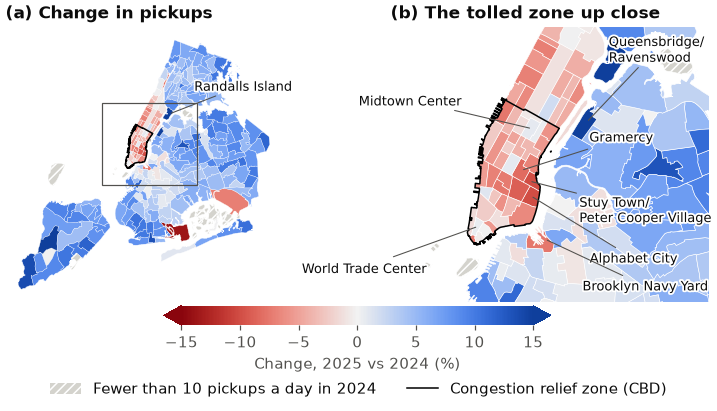

fhvhv: 256 zones shown


Statistic,Change (%),"Earnings per hour, change (%)"
Count,256.0,256.0
Mean,3.5,2.2
Standard deviation,5.8,1.5
Min,-13.8,-1.5
25%,0.3,1.2
50%,4.6,2.2
75%,7.4,3.3
Max,26.3,5.6


In [18]:
zone_medians = {s: explore.zone_medians(trips[s]) for s in config.SERVICES}
zone_changes = {s: explore.zone_change(summary[summary["service"] == s],
                                       zone_medians[s])
                for s in config.SERVICES}
shapes = zones.load_zone_shapes()
too_few = f"Fewer than {explore.MIN_DAILY_PICKUPS} pickups a day in 2024"

# The zones the report names, so a reader can find each one on the map.
# Only those: a label on a zone the text never discusses is clutter.
# Offsets are in points from the zone and were set by eye: the CBD zones
# are named in the blank margin west of Manhattan, and the zones east of
# it in the space over Queens and Brooklyn
city_labels = {"Randalls Island": (16, 14)}
zoom_labels = {"Midtown Center": (-46, 14),
               "World Trade Center": (-34, -22),
               "Queensbridge/Ravenswood": (14, 38),
               "Gramercy": (44, 16),
               "Stuy Town/Peter Cooper Village": (32, -10),
               "Alphabet City": (38, -36),
               "Brooklyn Navy Yard": (24, -26)}

# Only pickups are mapped. Earnings per engaged hour move by a few percent,
# so a choropleth of them is near-uniform whatever the scale; the scatter
# below shows the same numbers against pickups, which is what matters.
# This is the report's zone map
fig = plots.zone_maps(shapes, zone_labels, zone_changes["fhvhv"],
                      ["change_pct"], ["Change in pickups"], [15], too_few,
                      city_labels=city_labels, zoom_labels=zoom_labels)
plots.save(fig, "fig2_zone_map")
plt.show()

for service in config.SERVICES:
    shown = zone_changes[service][zone_changes[service]["enough_trips"]]
    print(f"{service}: {len(shown)} zones shown")
    display(plots.flat(  # noqa: F821
        shown[["change_pct", "eph_change_pct"]].describe().round(1)
        .rename_axis("statistic")))


In [19]:
# Uber/Lyft zones with the biggest changes in pickups, among zones shown
names = zone_labels.set_index("LocationID")[["Zone", "zone_group_fine"]]
shown = (zone_changes["fhvhv"][zone_changes["fhvhv"]["enough_trips"]]
         .join(names, on="PULocationID")
         [["PULocationID", "Zone", "zone_group_fine", "daily_before",
           "change_pct", "eph_before", "eph_after", "eph_change_pct"]])
print("Biggest falls in pickups")
display(plots.flat(  # noqa: F821
    shown.nsmallest(10, "change_pct").round(1)))
print("Biggest rises in pickups")
display(plots.flat(  # noqa: F821
    shown.nlargest(10, "change_pct").round(1)))

# Median of the zone changes in each fine zone group
plots.flat(shown.groupby("zone_group_fine")
           [["change_pct", "eph_change_pct"]]
           .median().round(1).reindex(clean.ZONE_GROUPS))

Biggest falls in pickups


Pickup zone ID,Zone,Fine zone group,"Pickups a day, before",Change (%),"Earnings per hour, before ($)","Earnings per hour, after ($)","Earnings per hour, change (%)"
154,Marine Park/Floyd Bennett Field,"Control, far",68.9,-13.8,61.0,60.2,-1.3
4,Alphabet City,CBD,2051.9,-10.1,54.5,56.3,3.3
224,Stuy Town/Peter Cooper Village,CBD,1454.6,-10.0,53.7,55.8,4.0
79,East Village,CBD,8693.4,-9.0,54.2,56.1,3.5
107,Gramercy,CBD,5196.4,-8.2,53.6,55.2,3.0
120,Highbridge Park,"Control, far",64.6,-8.0,58.4,59.8,2.5
34,Brooklyn Navy Yard,"Ring, across water",609.9,-7.6,53.6,55.6,3.8
114,Greenwich Village South,CBD,4252.3,-7.6,53.9,56.1,4.1
12,Battery Park,CBD,73.8,-7.5,54.6,57.4,5.2
50,Clinton West,CBD,3789.3,-7.5,54.0,55.6,3.0


Biggest rises in pickups


Pickup zone ID,Zone,Fine zone group,"Pickups a day, before",Change (%),"Earnings per hour, before ($)","Earnings per hour, after ($)","Earnings per hour, change (%)"
194,Randalls Island,"Control, far",110.2,26.3,98.1,102.6,4.6
193,Queensbridge/Ravenswood,"Ring, across water",940.9,18.9,53.1,54.4,2.4
99,Freshkills Park,"Control, far",13.8,18.1,65.9,66.4,0.7
57,Corona,"Control, far",136.3,17.5,59.6,59.9,0.6
44,Charleston/Tottenville,"Control, far",250.2,13.7,70.1,69.8,-0.3
29,Brighton Beach,"Control, far",1203.5,13.3,55.3,55.6,0.6
83,Elmhurst/Maspeth,"Control, far",1426.5,13.1,54.3,54.9,1.1
172,New Dorp/Midland Beach,"Control, far",387.4,11.9,58.8,59.9,1.7
101,Glen Oaks,"Control, far",383.0,11.6,67.5,67.6,0.3
106,Gowanus,"Control, far",1300.6,11.4,52.2,53.8,3.2


Fine zone group,Change (%),"Earnings per hour, change (%)"
CBD,-4.3,4.1
"Ring, adjacent",-3.8,2.4
"Ring, across water",2.5,3.5
"Control, near",0.6,2.9
"Control, far",5.9,1.7


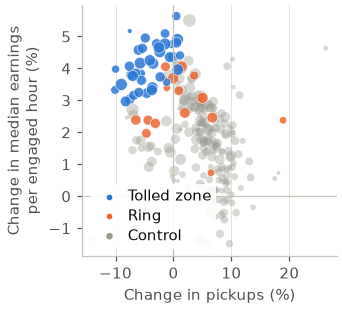

Group,Zones,Spearman
all shown,256,-0.56
CBD,38,0.50
Ring,18,-0.11
Control,200,-0.39


CBD zones shown: 38, 33 with fewer pickups, 38 paying more an hour


Statistic,"Earnings per hour, before ($)","Earnings per hour, after ($)",Change (%),"Earnings per hour, change (%)"
Count,38.00,38.00,38.00,38.00
Mean,54.99,57.26,-4.16,4.11
Standard deviation,1.70,1.97,3.24,0.67
Min,52.16,54.14,-10.08,2.97
25%,53.62,55.82,-6.78,3.58
50%,54.65,56.67,-4.34,4.11
75%,55.81,58.31,-1.46,4.65
Max,59.61,62.44,1.13,5.64


In [20]:
# The report's zone scatter: the two changes of the map on one
# pair of axes
fig = plots.zone_scatter(zone_changes["fhvhv"], zone_labels)
plots.save(fig, "fig3_zone_scatter")
plt.show()

# How the two changes move together, over all zones shown and by group
display(plots.flat(  # noqa: F821
    explore.zone_correlation(zone_changes["fhvhv"], zone_labels).round(2)))

# Earnings per engaged hour in the 38 CBD zones: every one of them rose
cbd_zones = (zone_changes["fhvhv"].join(names, on="PULocationID")
             .query("enough_trips and zone_group_fine == 'cbd'"))
print(f"CBD zones shown: {len(cbd_zones)}, "
      f"{(cbd_zones['change_pct'] < 0).sum()} with fewer pickups, "
      f"{(cbd_zones['eph_change_pct'] > 0).sum()} paying more an hour")
plots.flat(cbd_zones[["eph_before", "eph_after", "change_pct",
                      "eph_change_pct"]].describe().round(2)
           .rename_axis("statistic"))

### 5.5 Change by time band and day of week

For each time band and day of week, how much trips touching the CBD changed **on their own** (panel a) and **compared with control trips** (panel b): (1 + treated change) / (1 + control change) - 1. A value of -8 means treated trips ended up 8% lower than if they had changed the way control trips did, a raw version of the difference-in-differences estimate in Section 6.

The first figure is the report's (`fig4_band_day.pdf`). The control changes behind it follow in the notebook only.

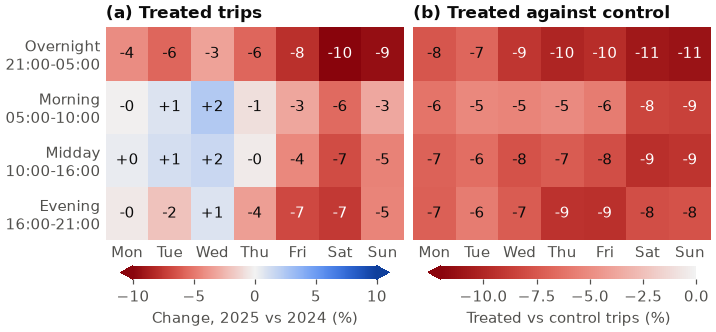

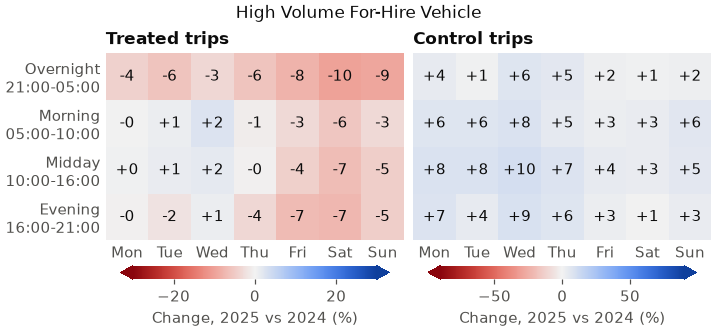

In [21]:
band_day = explore.band_day_change(summary)

# The report's time-band figure: the treated change on its own,
# and relative to control. Each panel gets its own scale, because
# (b) is one-signed and a scale wide enough for (a) would leave
# it almost flat
fig = plots.band_day_heatmaps(
    [explore.band_day_table(band_day, "fhvhv", "treated"),
     explore.relative_change(band_day, "fhvhv")],
    ["(a) Treated trips", "(b) Treated against control"],
    limits=[10, (-12, 0)],
    labels=["Change, 2025 vs 2024 (%)", "Treated vs control trips (%)"])
plots.save(fig, "fig4_band_day")
plt.show()

# The control changes behind the figure (notebook only)
for service in config.SERVICES:
    tables = [explore.band_day_table(band_day, service, g)
              for g in ["treated", "control"]]
    fig = plots.band_day_heatmaps(
        tables, ["Treated trips", "Control trips"], limits=[30, 90],
        labels=["Change, 2025 vs 2024 (%)"] * 2)
    fig.suptitle(plots.SERVICE_NAMES[service])
    plt.show()


### 5.6 High volume for-hire vehicle pickup wait

The time from a ride request to the pickup (`pickup_datetime` minus `request_datetime`), averaged over each year's monthly medians and 90th percentiles. `on_scene_datetime`, when the driver arrives, would be closer to what we want, but the data dictionary says it is only recorded for accessible vehicles. A longer wait suggests fewer free drivers for the passengers asking; a shorter one, more drivers than passengers.

In [22]:
# Average of the monthly medians and 90th percentiles, by year
wait = explore.pickup_wait(trips["fhvhv"])
plots.flat(wait.assign(year=wait["month"].dt.year)
           .groupby(["year", "trip_group_coarse"])
           [["median_wait_min", "p90_wait_min"]]
           .mean().unstack("trip_group_coarse").round(2))

### 5.7 What an engaged hour buys

Earnings per engaged hour rises either because trips pay more or because the same hour covers more ground, and the trips themselves can tell the two apart. The first two tables give the median speed, distance, length and pay per engaged hour of high volume for-hire vehicle trips picked up in the CBD, the ring and the control zones, before and after the toll, and the change between them. They also give the share of trips with no engaged hour of their own: shared rides and trips whose distance was never measured.

The last table is the outside check: the MTA's monthly average taxi and for-hire vehicle speed in the CBD, the area next to it and the rest of the city, which measures every vehicle rather than only the ones carrying a passenger. The file ends in August 2025, so January-August 2025 is compared with the same months of 2024.

In [23]:
# Speed, distance and pay of the same trips that produced the
# earnings change of Section 5.4, by the group they were picked up in
engaged_hour = explore.engaged_hour_by_group(trips["fhvhv"])
display(plots.flat(engaged_hour.round(2)))  # noqa: F821

# The same table as before, after and the change between them
plots.flat(explore.engaged_hour_change(engaged_hour).round(2),
           merge=["measure"])

Pickup group,Period,Trips,Shared rides (%),Earnings per hour known (%),Median speed (mph),Median distance (mi),Median trip time (min),Median earnings per hour ($)
CBD,before,62558282,1.50,98.49,10.01,2.80,18.23,54.88
CBD,after,60103498,1.07,98.92,10.23,2.88,18.28,57.13
Ring,before,20584871,1.59,98.40,10.74,3.13,17.47,53.69
Ring,after,20725620,1.39,98.61,10.71,3.09,17.32,55.28
Control,before,147548546,1.65,98.34,11.84,2.94,14.97,54.95
Control,after,153056773,1.93,98.07,11.68,2.86,14.78,55.95


In [24]:
plots.flat(explore.speed_change(external_files["cbd_speeds"]).round(2))

Zone,Before (mph),After (mph),Change (%)
CBD,8.74,9.01,3.09
CBD Adjacent,12.60,12.46,-1.12
Greater NYC,16.66,16.52,-0.90


## 6. Models

Both models are fitted to the model table of Section 4, one service at a time. Pickup zone, drop-off group, time band, day of week and month are **categorical** inputs; rain, snowfall, snow depth and the maximum and minimum temperature are **continuous**; the holiday flag is 0 or 1. Every effect is given in percent relative to control trips. The functions are in `scripts/models.py`.

### 6.1 Model 1: difference-in-differences

Trips touching the CBD are compared with control trips, before and after 5 January 2025, so that anything hitting the whole city cancels. Ring trips are kept out of the control group and each ring half gets its own after-toll term, which measures the spillover instead of hiding it.

- **Trips:** a Poisson regression of trips per cell, because many cells have 0 trips and log(0) is undefined.
- **Earnings per engaged hour:** OLS on the log of each cell's median, weighted by the cell's trips with known earnings.
- **Fixed effects** for each pickup zone x drop-off group x time band, and for each date x time band, which absorb the after-toll flag, day of week, holidays and citywide weather band by band.
- **`treated` x each weather column**, in case weather moves demand inside the CBD differently, and **errors clustered by pickup zone**.

`did_checks` fits this headline model and every check in Sections 6.3-6.4, for both outcomes. The table shows the headline terms and, beside them, the same model with one pooled ring term. `Rows` is the number of rows each fit used.

In [25]:
did_effects = pd.concat(
    {s: models.did_checks(models.did_data(model_table, s))
     for s in config.SERVICES}, names=["service"])
effect_columns = ["effect_pct", "ci_low_pct", "ci_high_pct"]

# Headline toll terms, and the pooled ring term of the same model
plots.flat(did_effects.query("check in ['headline', 'pooled ring']")
           [effect_columns + ["rows"]].droplevel("term").round(1),
           merge=["service", "outcome", "check"])

### 6.2 Event study: is it the toll, or a trend?

The headline model gives one number for the whole toll period. Here the trips model is fitted again with a `treated`, `ring_adjacent` and `ring_across` term for every month, relative to December 2024. If trips inside and outside the zone were following the same trend before the toll (the parallel trends assumption), the months before January 2025 sit near 0. The figure is the report's event study (`fig5_event_study.pdf`).

Trips are summed to months first, with a fixed effect for each cell and each month x time band, because 105 month terms on a service's 5.8M daily rows would need about 5 GB per copy of the data. There is no weather term: monthly weather has one value per month, which the month terms already absorb.

The first table gives the treated estimates by calendar month and year; the second, the change from the same month a year earlier, in percentage points.

INFO:fontTools.subset:maxp pruned


INFO:fontTools.subset:cmap pruned


INFO:fontTools.subset:kern dropped


INFO:fontTools.subset:post pruned


INFO:fontTools.subset:FFTM dropped


...

INFO:fontTools.subset:glyf pruned


INFO:fontTools.subset:GDEF pruned


INFO:fontTools.subset:GPOS pruned


INFO:fontTools.subset:GSUB pruned


INFO:fontTools.subset:name pruned


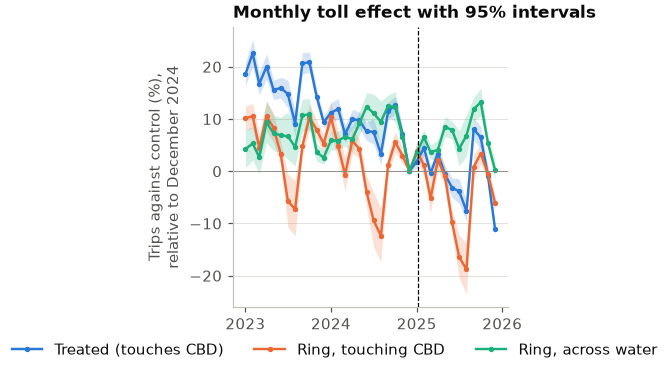

In [26]:
events = {s: models.event_study(model_table, s)
          for s in config.SERVICES}

# The report's event study: the monthly treated and ring terms
# with their 95% intervals
fig = plots.event_study(events, config.TOLL_START_DATE)
plots.save(fig, "fig5_event_study")
plt.show()

treated = (pd.concat(events, names=["service"]).reset_index("service")
           .query("group == 'treated'"))
by_month = treated.pivot_table(
    index=treated["month"].dt.month.rename("month_of_year"),
    columns=["service", treated["month"].dt.year.rename("year")],
    values="effect_pct")
display(plots.flat(by_month.round(1)))  # noqa: F821

# Change from the same month a year earlier (percentage points)
same_month = by_month.T.groupby(level="service").diff().dropna()
plots.flat(same_month.agg(["min", "mean", "max"], axis=1).round(1),
           merge=["service"])

### 6.3 Checks on the headline estimate

Four checks:

- **Placebo:** 2023-2024 only, with a fake toll on 5 January 2024. There was no toll, so any "effect" found is a trend or chance.
- **2024-2025 only:** the toll period against 2024 alone, so a trend that ran through 2023 moves the estimate less.
- **Linear trends:** the headline model plus a straight-line trend for the treated group and each ring half (the `trend` rows, change per year). The toll terms then measure the break from each group's own trend.
- **Buffer band dropped:** control trips with an end in `control_near` are left out, so both ends of every remaining control trip are more than 2 km from the CBD.

In [27]:
checks = ["headline", "placebo", "2024-2025 only", "linear trends",
          "buffer band dropped"]
plots.flat(did_effects.query("check in @checks")[effect_columns + ["rows"]]
           .round(1), merge=["service", "outcome", "check"])

### 6.4 Toll effect by time band

The headline model again, with one treated and one ring term for each time band in place of the whole-day terms. The ring is pooled here, to keep the number of terms down. The date fixed effects are separate for each band, so each term picks up only the change in that band.

In [28]:
plots.flat(did_effects.query("check == 'by time band'")[effect_columns]
           .droplevel("check").round(1),
           merge=["service", "outcome", "group"])

### 6.5 Earnings per engaged hour in dollars

Model 1's headline percentage for treated trips, times the median earnings per engaged hour of every treated trip in the 2024 period, from Spark.

In [29]:
headline_eph = did_effects.xs(("log_eph", "headline", "treated", "all"),
                              level=["outcome", "check", "group", "term"])
for service in config.SERVICES:
    median = models.median_eph_before(trips[service])
    effect = headline_eph.loc[service]
    print(f"{service}: 2024 median ${median:.2f} an hour; "
          f"{effect['effect_pct']:+.1f}% is "
          f"{median * effect['effect_pct'] / 100:+.2f} $ an hour "
          f"(95% CI {median * effect['ci_low_pct'] / 100:+.2f} to "
          f"{median * effect['ci_high_pct'] / 100:+.2f})")

fhvhv: 2024 median $55.26 an hour; +2.2% is +1.23 $ an hour (95% CI +1.07 to +1.39)


### 6.6 Model 2: LightGBM forecast

Model 1 removes confounders by design and needs parallel trends to do it. Model 2 drops that assumption for a forecasting question: trained only on what happened before the toll, what would the toll year have looked like? LightGBM adds up hundreds of small decision trees, each fitted to the errors left by the ones before it, so it finds interactions such as a zone busy only on weekend nights without them being written in. It takes the inputs listed at the start of Section 6, `year` as a number, and `usual`, the cell's mean over the training rows only, so no later data leaks in.

Trips are counts, so the trips model uses a Poisson objective; total earnings are 0 in empty cells and continuous elsewhere, which a Tweedie objective fits. The settings (`models.LGBM_PARAMS`) were not tuned, since the model has to forecast a counterfactual rather than win on accuracy.

**Validation:** train on 2023 and test on all of 2024, both before the toll. WMAPE is the sum of absolute errors as a share of the sum of actual values; plain MAPE breaks on cells with very few trips. The baseline forecasts each cell with its value on the same weekday 52 weeks earlier.

In [30]:
validation = {s: models.validate(model_table, s) for s in config.SERVICES}
plots.flat(pd.concat({s: v[0] for s, v in validation.items()},
                     names=["service"]).round(2),
           merge=["service", "target"])

The same fit read in a year with no toll: 2024, read the way Section 6.7 reads the toll period. It is Model 1's placebo of Section 6.3 by the other method, and it sizes what any toll-period figure has to clear.

In [31]:
placebos = {service: models.forecast_placebo(model_table, service)
            for service in config.SERVICES}
plots.flat(pd.concat(placebos, names=["service"]).round(1),
           merge=["service", "target"])

### 6.7 Forecast of the toll period

Model 2 is refitted on 2023-2024 and forecasts every cell and day of the toll period. `year` lets the refit follow the change from 2023 to 2024; trees can't extrapolate, so 2025 is forecast as a year like 2024.

The gap between actual and forecast also holds everything that changed citywide in 2025, so the toll effect is each group's gap relative to the gap for control trips: (1 + group gap) / (1 + control gap) - 1. That is on the same scale as Model 1.

In [32]:
forecasts, shap_values = {}, {}
for service in config.SERVICES:
    for target in models.OBJECTIVES:
        model, inputs, rows = models.forecast(model_table, service, target)
        forecasts[service, target] = rows
        if target == "trips":
            shap_values[service] = models.shap_importance(model, inputs)

plots.flat(pd.concat({key: models.forecast_effect(rows)
                      for key, rows in forecasts.items()},
                     names=["service", "target"]).round(1),
           merge=["service", "target"])

### 6.8 Which inputs matter (SHAP)

SHAP values split each forecast into one additive part per input, so an input's mean absolute SHAP value measures how far it moves the forecasts. These are for the two trips models, on the log scale of the Poisson objective, over a random sample of 20,000 toll-period rows, because their run time grows with the number of rows.

In [33]:
plots.flat(pd.DataFrame(shap_values).sort_values("fhvhv", ascending=False)
           .round(3).rename_axis("input"))

Input,High Volume For-Hire Vehicle
Usual level,2.091
Day of week,0.099
Time band,0.033
Pickup zone ID,0.028
Month,0.018
Year,0.011
Max temperature (°C),0.011
Dropoff group,0.009
Min temperature (°C),0.007
Rain (mm),0.006


### 6.9 The two models compared

Each model's toll effect relative to control trips, for the whole day, for treated trips in each time band and for each ring half. This is the report's model table. Model 1's effects come from the headline and time-band fits, with 95% intervals; Model 2 has no interval. Model 1 measures earnings per engaged hour and Model 2 total earnings, so those two columns answer different questions.

In [34]:
model_comparison = pd.concat(
    {s: models.comparison(did_effects.loc[s],
                          {t: forecasts[s, t] for t in models.OBJECTIVES})
     for s in config.SERVICES}, names=["service"])
plots.flat(model_comparison.round(1), merge=["service", "group"])

## 7. Recommendations

### 7.1 Pickup zone against the no-toll forecast

Section 6.9 read Model 2's forecast of the toll period by trip group. Read instead by **pickup zone and time band**, the same forecast answers the question a driver asks: if I start a shift here, in this band, how did the toll period turn out against a year the toll never happened in?

`gap_pct` is 100 x (actual / forecast - 1) over the whole toll period, for trips and for total earnings. It is the gap itself, **not** divided by the control gap the way Section 6.9's effects are, so it still holds everything else that changed in 2025. The saved table keeps the control-adjusted `effect_pct` beside it, on the same scale as Section 6.9.

The full 265-zone table goes to `data/curated/driver_heatmap.csv`, which is the zone-by-zone table the report's recommendations rest on. The first table below shows the 15 busiest pickup zones; the second carries the pattern to all zones, as the median zone's gap in each zone group and band. The 15 are also the report's driver figure (`fig6_driver_heatmap.pdf`), which puts each zone's gap in trips beside its gap in total earnings on one colour scale, so a row reads across both panels. The scale runs to 12%, and the few cells past it keep the end colour.

Zone x time band table: 1,060 rows x 12 columns, saved to data/curated. The 15 zones shown hold 17.8% of high volume for-hire vehicle trips in the toll period


INFO:fontTools.subset:maxp pruned


INFO:fontTools.subset:cmap pruned


INFO:fontTools.subset:kern dropped


INFO:fontTools.subset:post pruned


...

INFO:fontTools.subset:glyf pruned


INFO:fontTools.subset:GDEF pruned


INFO:fontTools.subset:GPOS pruned


INFO:fontTools.subset:GSUB pruned


INFO:fontTools.subset:name pruned


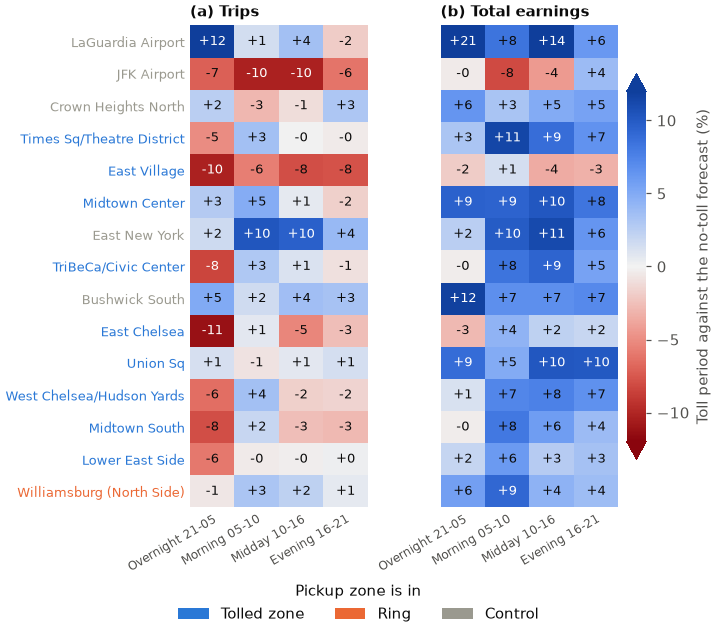

In [35]:
# Model 2's toll period against its no-toll forecast, by pickup zone and
# time band, from the forecasts already fitted in Section 6.7
zone_bands = pd.concat(
    {s: models.zone_band_gaps({t: forecasts[s, t]
                               for t in models.OBJECTIVES}, zone_labels)
     for s in config.SERVICES}, names=["service"]).reset_index(level=0)
zone_bands.to_csv(config.CURATED_DIR / "driver_heatmap.csv", index=False)

fhvhv_bands = zone_bands[zone_bands["service"] == "fhvhv"]
share = (fhvhv_bands.loc[fhvhv_bands["shown"], "trips"].sum()
         / fhvhv_bands["trips"].sum())
print(f"Zone x time band table: {len(zone_bands):,} rows x "
      f"{zone_bands.shape[1]} columns, saved to data/curated. "
      f"The 15 zones shown hold {share:.1%} of high volume for-hire "
      "vehicle trips in the toll period")

# The report's driver figure: the same 15 zones as the table below
fig = plots.driver_heatmap(fhvhv_bands[fhvhv_bands["shown"]],
                           ["trips_gap_pct", "total_earnings_gap_pct"],
                           ["(a) Trips", "(b) Total earnings"], 12,
                           "Toll period against the no-toll forecast (%)")
plots.save(fig, "fig6_driver_heatmap")
plt.show()

# The 15 busiest high volume for-hire vehicle pickup zones, busiest first
plots.flat(fhvhv_bands.loc[fhvhv_bands["shown"],
                           ["Zone", "zone_group", "time_band", "trips",
                            "trips_gap_pct", "total_earnings_gap_pct"]]
           .round(1), merge=["Zone", "zone_group"])

In [36]:
# All 265 zones, not just the 15 shown: the median zone's gap in each
# zone group and band, for high volume for-hire vehicle
plots.flat(fhvhv_bands.groupby(["zone_group", "time_band"], observed=True)
           [["trips_gap_pct", "total_earnings_gap_pct"]].median().round(1)
           .reindex(["cbd", "ring", "control"], level="zone_group"),
           merge=["zone_group"])